<!-- NINO26-CABECALHO v1 -->
# 4C — Sinal pixel-a-pixel, por região IBGE e por bioma

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `4C`  ·  **Hipótese:** HIP1

## Descritivo (por que este notebook existe)
Distribui o sinal Pacífico->chuva por pixel, região e bioma, por fase do ciclo — o coração espacial da teleconexão e o que sustenta ou refuta a hipótese NEB seco/Sul úmido.

## Pergunta
Onde, quando e com que sinal (seco/úmido) e em que lag o Pacífico altera a chuva do Brasil, por pixel/região/bioma?

## Desafio (hipótese a testar)
O alvo CHIRPS precisa ser uma anomalia interpretável (não o z corrompido) e a significância exige N_eff+FDR; só pixels do Brasil entram.

## Metodologia (com referências)
Correlação defasada Pacífico(t-lag)->anomalia de chuva(t) com Pearson exato, N_eff de Bretherton e FDR-BH, em três suportes espaciais (Grimm & Tedeschi, 2009; Bretherton et al., 1999; Benjamini & Hochberg, 1995; Funk et al., 2015).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_4C01", fase=4, bloco="C",
                 titulo=..., descricao=..., hipotese="HIP1",
                 notebook="notebooks/fase4/4C_sinal_pixel_lags.ipynb",
                 fontes={"<tabela>": df})   # -> figures/fase4/<codigo>.png + numeric-tables/fase4/<codigo>/
```

| Código | Figura (`figures/fase4/<código>.png`) | Numeric-table (`numeric-tables/fase4/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_4C01` | `Fig_4C01.png` | `Fig_4C01/` | lags por região/bioma (El Niño) |
| `Fig_4C02` | `Fig_4C02.png` | `Fig_4C02/` | lags por região/bioma (La Niña) |
| `Fig_4C03` | `Fig_4C03.png` | `Fig_4C03/` | mapa pixel r no melhor lag |
| `Fig_4C04` | `Fig_4C04.png` | `Fig_4C04/` | recorte NEB |
| `Fig_4C05` | `Fig_4C05.png` | `Fig_4C05/` | recorte Sul |
| `Fig_4C06` | `Fig_4C06.png` | `Fig_4C06/` | mapas Brasil por lag |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; validação por `python scripts/validar_figuras.py --strict`.

In [1]:
import sys, subprocess, pathlib
ROOT = pathlib.Path.cwd().parents[1] if pathlib.Path.cwd().name=='fase4' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT/'src')); sys.path.insert(0, str(ROOT))
import pandas as pd; from IPython.display import Image, display
STATS = ROOT/'data/processed/parquet/statistics'; FIGS = ROOT/'data/processed/figures/fase4'


In [2]:
# Pipeline completo (todos os preditores selecionados). Use --quick p/ validacao.
# No sandbox/maquina sem GPU, o membership usa centroide; em producao use exato.
from scripts.run_fase4c_regional import main as run4c  # noqa
run4c(['--quick'])   # troque por run4c([]) para todos os preditores


[4C] preditores=['nino34_ssta'] (contrato=quick:nino34_ssta)


[4C] unidades com serie valida=13 | semanas=2366


[tabela] data/processed/parquet/statistics/phase4C_lags_por_unidade.csv (5720 linhas)


[figura] Fig_4C1_lags_regiao_bioma_el_nino.png (heatmap unidade x fase, el_nino)


[figura] Fig_4C2_lags_regiao_bioma_la_nina.png (heatmap unidade x fase, la_nina)
[4C] concluido.


0

## Lag por regiao e bioma, por fase (El Nino e La Nina)


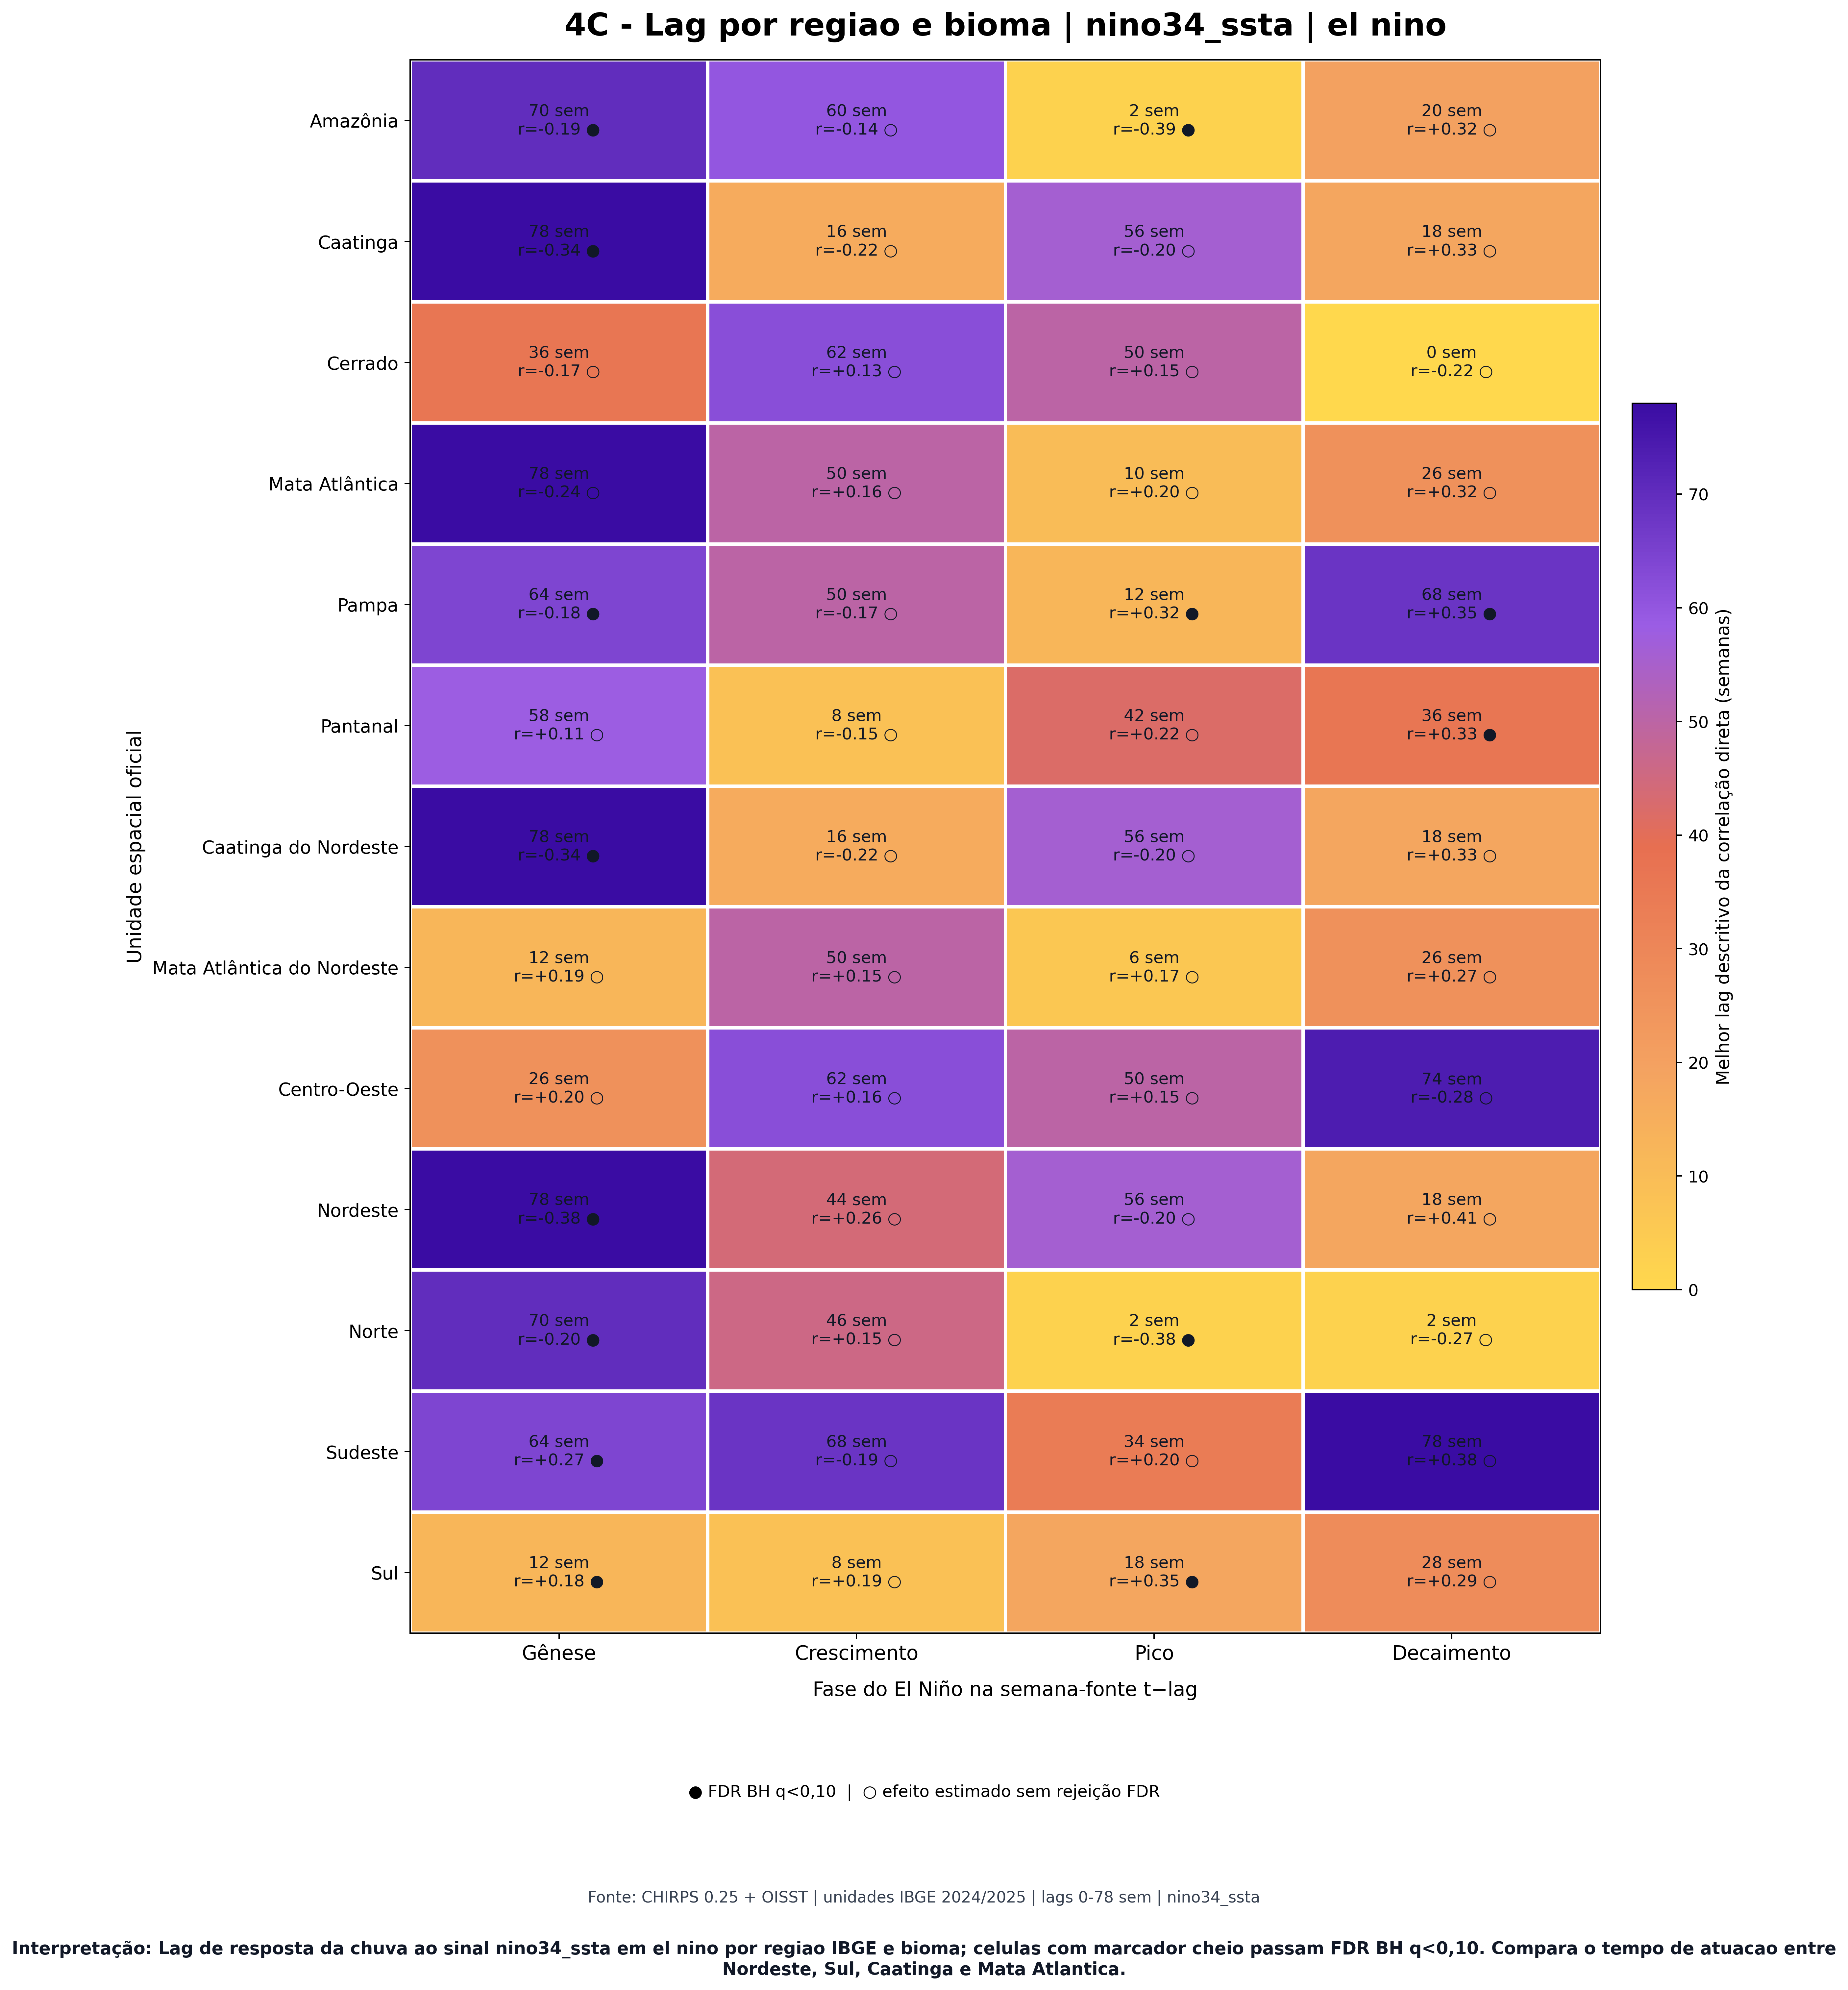

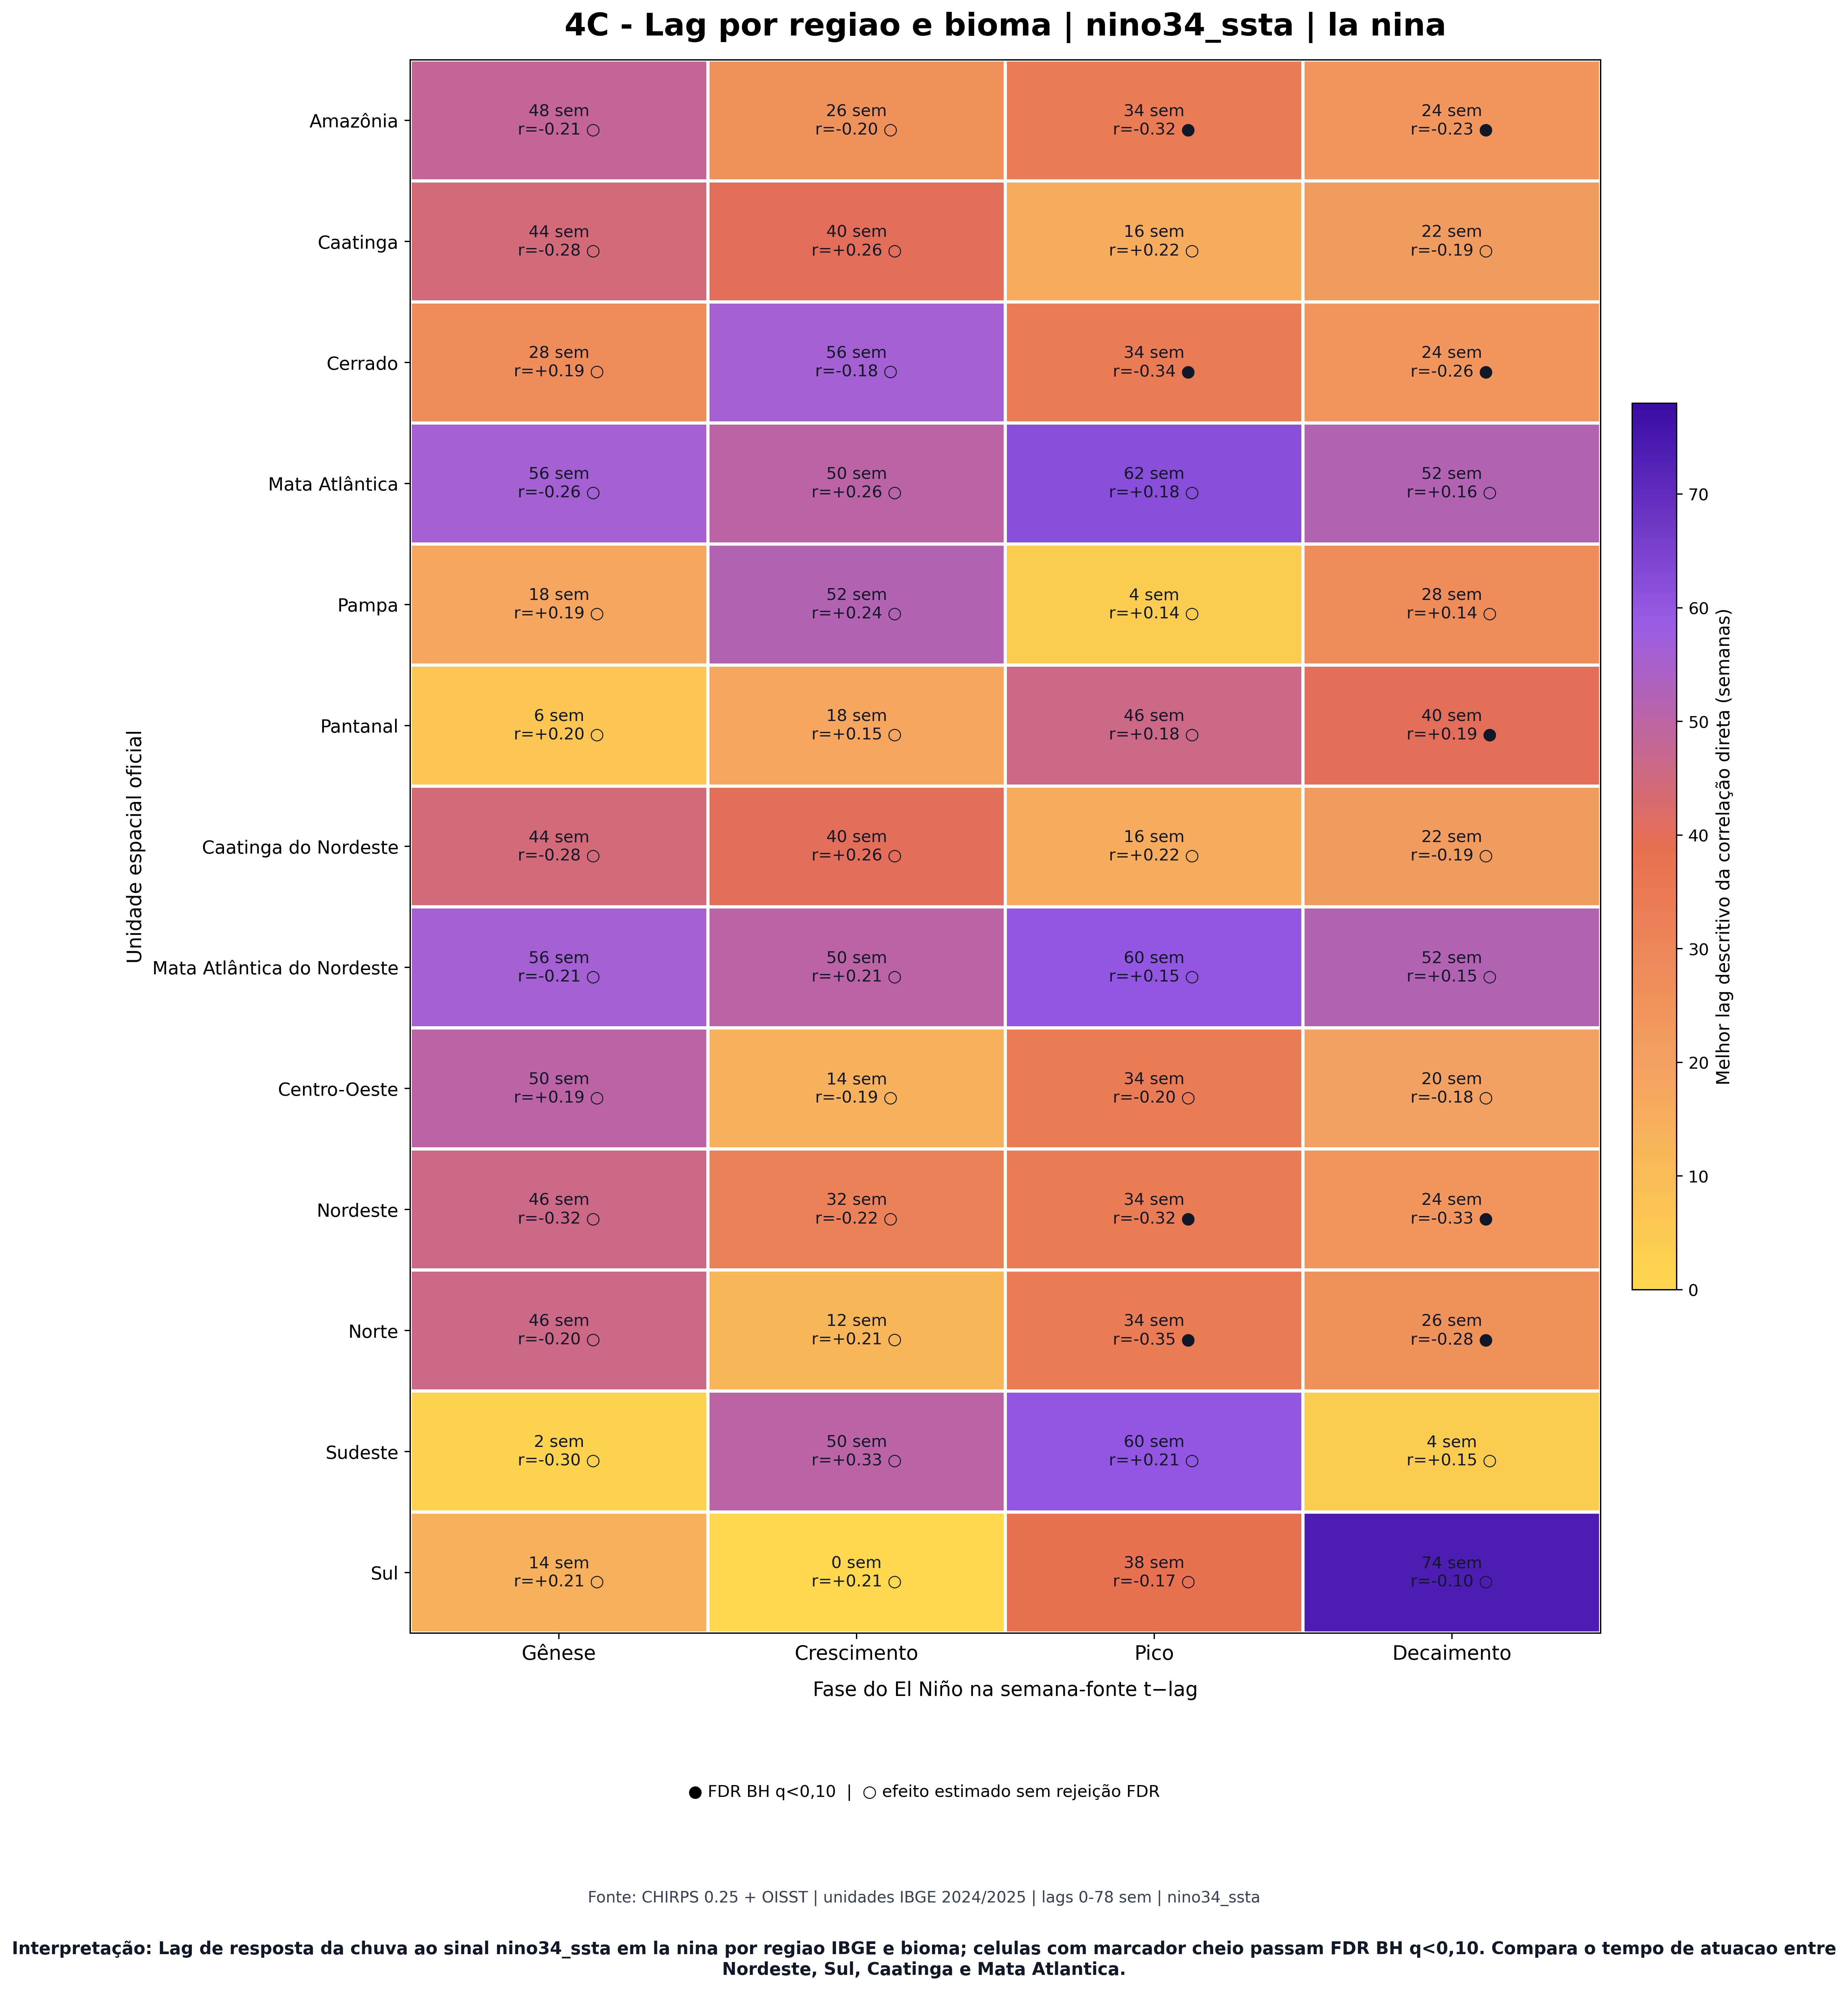

In [3]:
display(Image(str(FIGS/'Fig_4C1_lags_regiao_bioma_el_nino.png')))
display(Image(str(FIGS/'Fig_4C2_lags_regiao_bioma_la_nina.png')))


## Mapa pixel-a-pixel (grade preenchida, amarelo neutro)


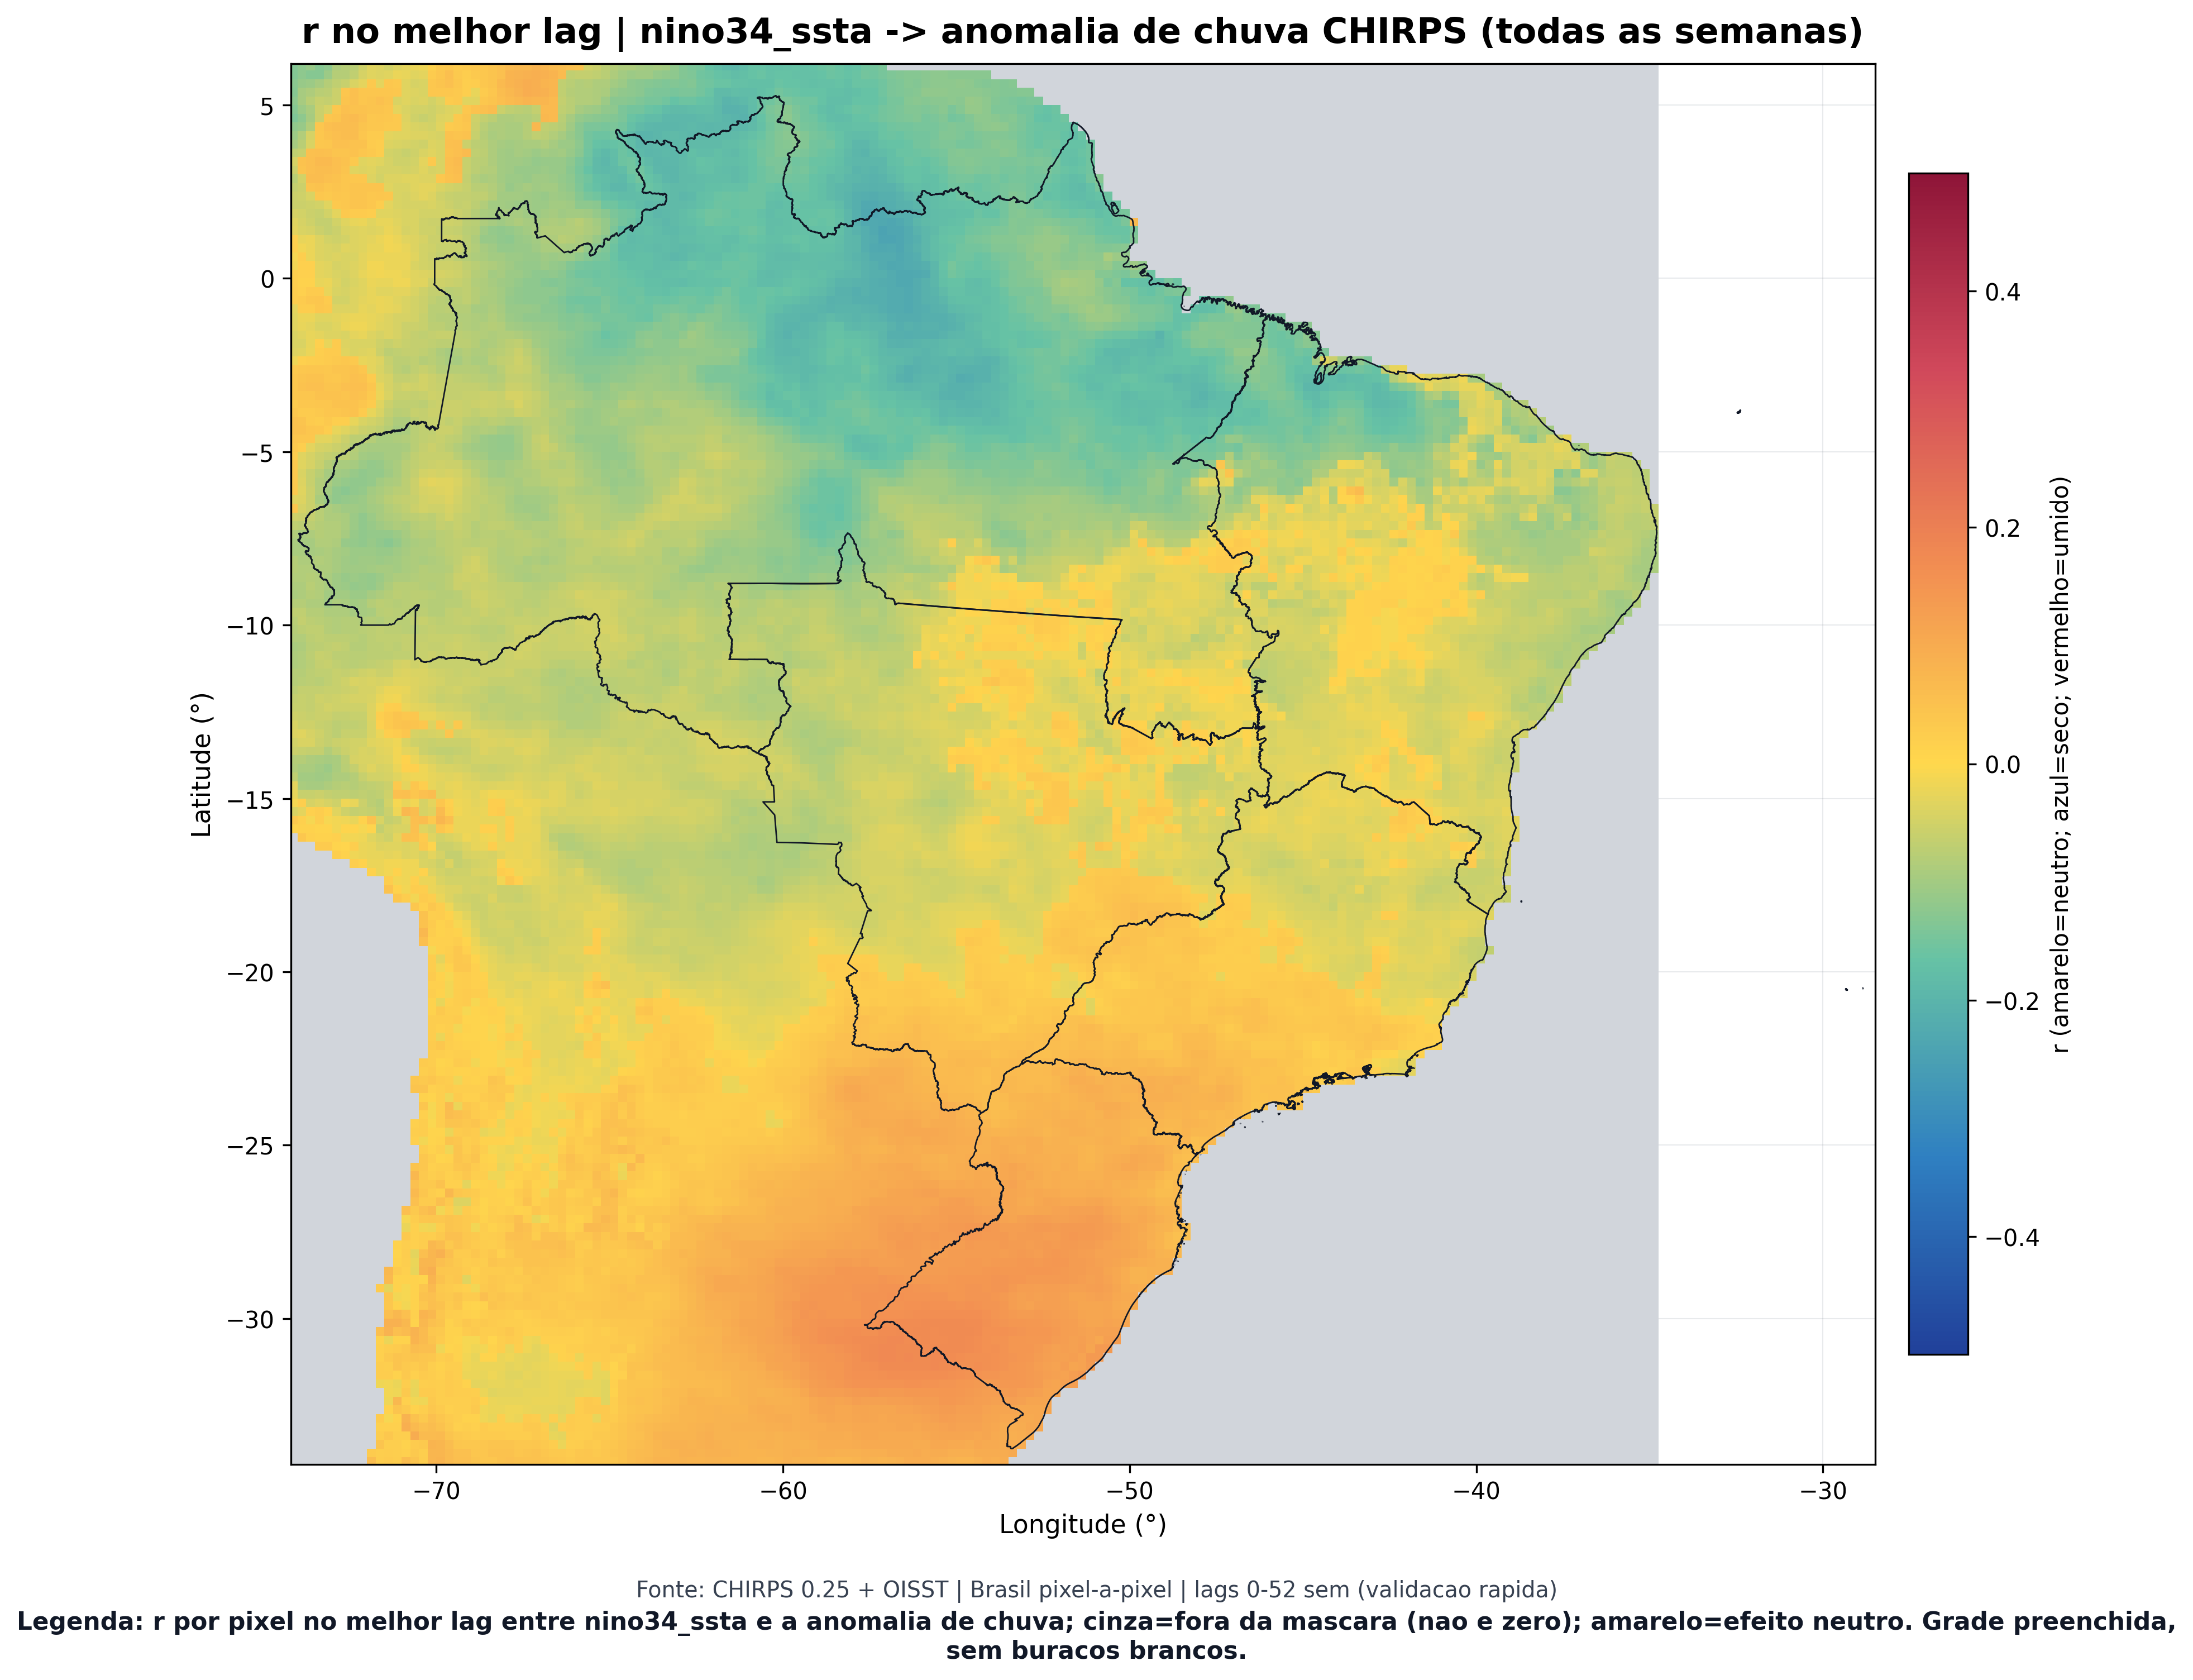

In [4]:
import pathlib as _p
f = FIGS/'Fig_4C3_mapa_pixel_r_melhor_lag.png'
display(Image(str(f))) if f.exists() else print('gere o mapa pixelar no modo completo')


**Leitura do 4C.** Nordeste/Caatinga: r negativo (seca) sob El Nino, com lag longo
na genese; Sul: r positivo (chuva) no pico. Cinza = fora da mascara (nao e zero);
amarelo = efeito neutro; marcador cheio / tracejado = FDR BH q<0,10.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Grimm, A. M., & Tedeschi, R. G. (2009). ENSO and Extreme Rainfall Events in South America. *J. Climate*, 22, 1589-1609. https://doi.org/10.1175/2008JCLI2429.1
2. Bretherton, C. S., et al. (1999). The Effective Number of Spatial Degrees of Freedom. *J. Climate*, 12, 1990-2009. https://doi.org/10.1175/1520-0442(1999)012<1990:TENOSD>2.0.CO;2
3. Benjamini, Y., & Hochberg, Y. (1995). Controlling the False Discovery Rate. *JRSS-B*, 57, 289-300. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x
4. Funk, C., et al. (2015). CHIRPS. *Scientific Data*, 2, 150066. https://doi.org/10.1038/sdata.2015.66
5. Cai, W., et al. (2020). Climate impacts of ENSO on South America. *Nat. Rev. Earth Environ.*, 1, 215-231. https://doi.org/10.1038/s43017-020-0040-3

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.